## Problema - Organización y búsqueda de productos en una tienda





## 1) Descripción del problema **[1 pts]**

Una plataforma de streaming registra la cantidad de nuevos suscriptores que se une cada mes, denota T(n) para el mes n. Se observa que

- En el mes 0 hubo suscriptores nuevos: T(0) = 0.
- En el mes 1 se registro 1 nuevo suscriptor: T(1) = 1.
- A paritr del segundo mes, los nuevos suscriptore de un mes proviene de dos fuente combinandas: los mencionados generaos por los sucriptores del mes inmediatamente anterio, y las recomendaciomes acumulaas desde el mes anterior a ese.

T(n) = T(n-1) + T(n-2), n ≥ 2

La mision es calcular T(n) de forma efectiva usando memorización, evitando recalcular subproblemas ya resueltos.

## 2) Requerimientos **[2 pts]**

Funcionales:

- Recibir un entero n >= 0 (mes) y retornar t(n).
- Manejar correctamente los casos base T(0) = 0 y T(1) = 1.
- Reutlizar resultados de subproblemas ya resueltos.

No Funcionales:

- Ejecutarse en tiempo O(n), no exponencial.
- Código claro, modular y comentado.
- Verificar con asserts.

## 3) Historias de usuario **[2 pts]**

**HU1.** *Como* analista de la plataforma, *quiero* consultar cuántos suscriptores nuevos habrá en el mes `n`, *para* proyectar el crecimiento de usuarios.
- *Criterio de aceptación:* dado un `n` entero no negativo, el sistema retorna el valor correcto de `T(n)`.

**HU2.** *Como* desarrollador, *quiero* que el cálculo reutilice resultados previos, *para* evitar recomputar subproblemas.

- *Criterio de aceptación:* con memoización se hacen O(n) llamadas efectivas, no O(2ⁿ).

**HU3.** *Como* usuario, *quiero* obtener resultados incluso para meses lejanos, *para* proyectar a largo plazo sin que falle.
- *Criterio de aceptación:* para `n=50`, retorna en menos de 1 segundo.

**HU4.** *Como* encargado de calidad, *quiero* pruebas automáticas, *para* confiar en los cálculos.
- *Criterio de aceptación:* existe un conjunto de `assert` que verifica casos base y valores conocidos.

## 4) Diagramas de flujo **[5 pts]**

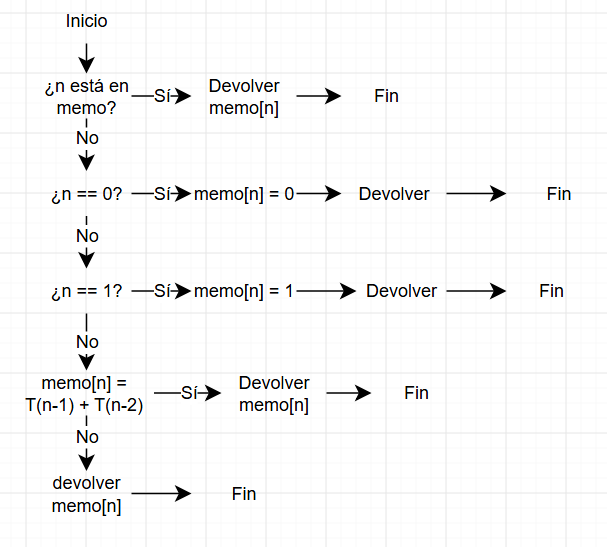

El algoritmo recibe un mes n. Primero verifica si el valor ya fue calculado antes; si es así, lo retorna directamente sin volver a calcularlo. Si no está en memoria, se evalúan los casos base: si n=0 el resultado es 0, si n=1 el resultado es 1. Para cualquier otro valor de n, el algoritmo hace dos llamadas recursivas — una para T(n-1) y otra para T(n-2) — suma sus resultados, guarda ese valor en la memoria para no recalcularlo en el futuro, y lo retorna. Este mecanismo de "guardar antes de retornar" es justamente lo que convierte una recursión exponencial en un algoritmo de tiempo lineal Θ(n).

### 5) Análisis de complejidad **[15 pts]**

**Justificación:** sin memoización, `T(n)=T(n-1)+T(n-2)` genera un árbol de llamadas donde muchos subproblemas (como `T(n-2)`) se recalculan una y otra vez. Con memoización, cada valor `T(k)` para `k=0,...,n` se calcula **una sola vez**.

$$T(n) = \begin{cases} 0 & n=0 \\ 1 & n=1 \\ T(n-1)+T(n-2) & n\ge 2\end{cases}$$

- **Sin memoización:** Θ(φⁿ), φ≈1.618 (exponencial).
- **Con memoización:** n+1 subproblemas distintos, cada uno O(1) adicional ⇒ **Θ(n)**. Mejor y peor caso coinciden (siempre se calculan los mismos n+1 estados). Espacio también Θ(n).

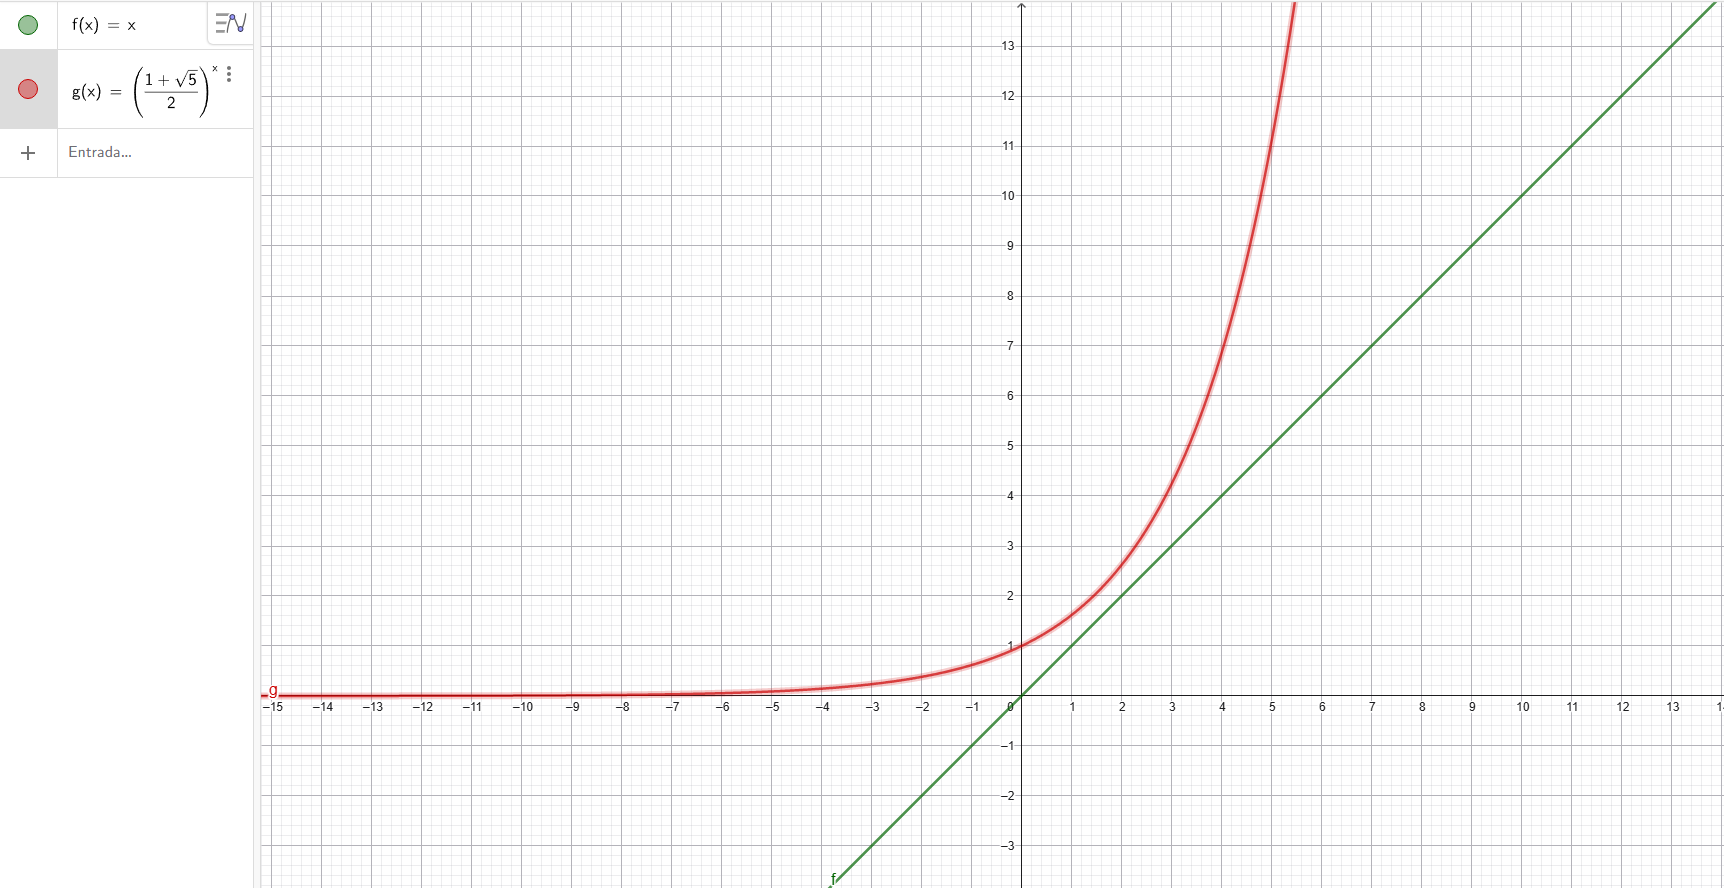

## 6) Código funcional **[15 pts]**


In [5]:
def suscriptores_memo(n, memo=None):
    if memo is None:
        memo = {}
    if n in memo:
        return memo[n]
    if n == 0:
        resultado = 0
    elif n == 1:
        resultado = 1
    else:
        resultado = suscriptores_memo(n - 1, memo) + suscriptores_memo(n - 2, memo)
    memo[n] = resultado
    return resultado


def suscriptores_tabulacion(n):
    if n == 0:
        return 0
    tabla = [0] * (n + 1)
    tabla[1] = 1
    for i in range(2, n + 1):
        tabla[i] = tabla[i - 1] + tabla[i - 2]
    return tabla[n]

# Ejemplo de uso
for mes in range(0, 11):
    print(f"Mes {mes}: {suscriptores_memo(mes)} nuevos suscriptores")

Mes 0: 0 nuevos suscriptores
Mes 1: 1 nuevos suscriptores
Mes 2: 1 nuevos suscriptores
Mes 3: 2 nuevos suscriptores
Mes 4: 3 nuevos suscriptores
Mes 5: 5 nuevos suscriptores
Mes 6: 8 nuevos suscriptores
Mes 7: 13 nuevos suscriptores
Mes 8: 21 nuevos suscriptores
Mes 9: 34 nuevos suscriptores
Mes 10: 55 nuevos suscriptores


## 7) Tests aplicados **[15 pts]**

In [3]:
assert suscriptores_memo(0) == 0
assert suscriptores_memo(1) == 1
assert suscriptores_memo(2) == 1 # T(2)=T(1)+T(0)=1+0=1
assert suscriptores_memo(3) == 2 # T(3)=T(2)+T(1)=1+1=2
assert suscriptores_memo(4) == 3 # T(4)=T(3)+T(2)=2+1=3
assert suscriptores_memo(5) == 5 # T(5)=T(4)+T(3)=3+2=5
assert suscriptores_memo(10) == 55

for n in range(0, 20):
    assert suscriptores_memo(n) == suscriptores_tabulacion(n)

print("Todos los tests pasaron correctamente.")

Todos los tests pasaron correctamente.
